# Proyek Klasifikasi Gambar: Garbage Classification

Notebook ini membangun model klasifikasi gambar sampah rumah tangga menggunakan dataset Garbage Classification. Alur pengerjaan dimulai dari load dataset, melihat contoh gambar dan variasi ukuran asli, membagi dataset secara manual, melatih model dengan transfer learning EfficientNetB0, mengevaluasi performa, lalu menyimpan model ke format SavedModel, TF-Lite, dan TFJS.

## Import Semua Packages/Library yang Digunakan

Bagian ini menyiapkan library utama untuk membaca dataset, membangun pipeline `tf.data`, membuat model transfer learning, menampilkan visualisasi, mengonversi model, dan menjalankan inference.

In [10]:
import shutil
import subprocess
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU tersedia: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Data Preparation

Dataset yang digunakan adalah Garbage Classification dari Kaggle. Dataset ini berisi gambar sampah rumah tangga yang tersusun dalam folder kelas seperti `battery`, `biological`, `cardboard`, `metal`, `paper`, `plastic`, dan kelas lainnya.

### Data Loading

Dataset dibaca langsung dari folder kelas. Setiap nama folder digunakan sebagai label, lalu seluruh path gambar dikumpulkan ke dalam array agar mudah dibagi menjadi train, validation, dan test set secara manual.

In [11]:
DATASET_DIR = Path("/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
CLASS_NAMES = np.array(sorted([path.name for path in DATASET_DIR.iterdir() if path.is_dir()]))
NUM_CLASSES = len(CLASS_NAMES)

file_paths = []
labels = []
class_counts = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_dir = DATASET_DIR / class_name
    image_paths = sorted(
        path for path in class_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    class_counts.append(len(image_paths))

    for image_path in image_paths:
        file_paths.append(str(image_path))
        labels.append(class_index)

file_paths = np.array(file_paths)
labels = np.array(labels, dtype=np.int32)
TOTAL_IMAGES = len(file_paths)

print("Folder dataset:", DATASET_DIR)
print("Jumlah gambar :", TOTAL_IMAGES)
print("Jumlah kelas  :", NUM_CLASSES)
print("\nJumlah gambar per kelas:")
for class_name, count in zip(CLASS_NAMES, class_counts):
    print(f"- {class_name}: {count}")

image_sizes = []
for image_path in file_paths:
    image = tf.io.decode_image(tf.io.read_file(image_path), channels=3, expand_animations=False)
    height, width = tf.shape(image).numpy()[:2]
    image_sizes.append((int(height), int(width)))

size_counter = Counter(image_sizes)
print("\nJumlah resolusi unik:", len(size_counter))
print("Contoh resolusi terbanyak:")
for (height, width), count in size_counter.most_common(8):
    print(f"- {height} x {width}: {count} gambar")

Folder dataset: /kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification
Jumlah gambar : 15515
Jumlah kelas  : 12

Jumlah gambar per kelas:
- battery: 945
- biological: 985
- brown-glass: 607
- cardboard: 891
- clothes: 5325
- green-glass: 629
- metal: 769
- paper: 1050
- plastic: 865
- shoes: 1977
- trash: 697
- white-glass: 775

Jumlah resolusi unik: 892
Contoh resolusi terbanyak:
- 533 x 400: 2590 gambar
- 384 x 512: 2358 gambar
- 225 x 225: 2004 gambar
- 534 x 400: 1077 gambar
- 183 x 275: 691 gambar
- 194 x 259: 550 gambar
- 400 x 533: 388 gambar
- 711 x 400: 300 gambar


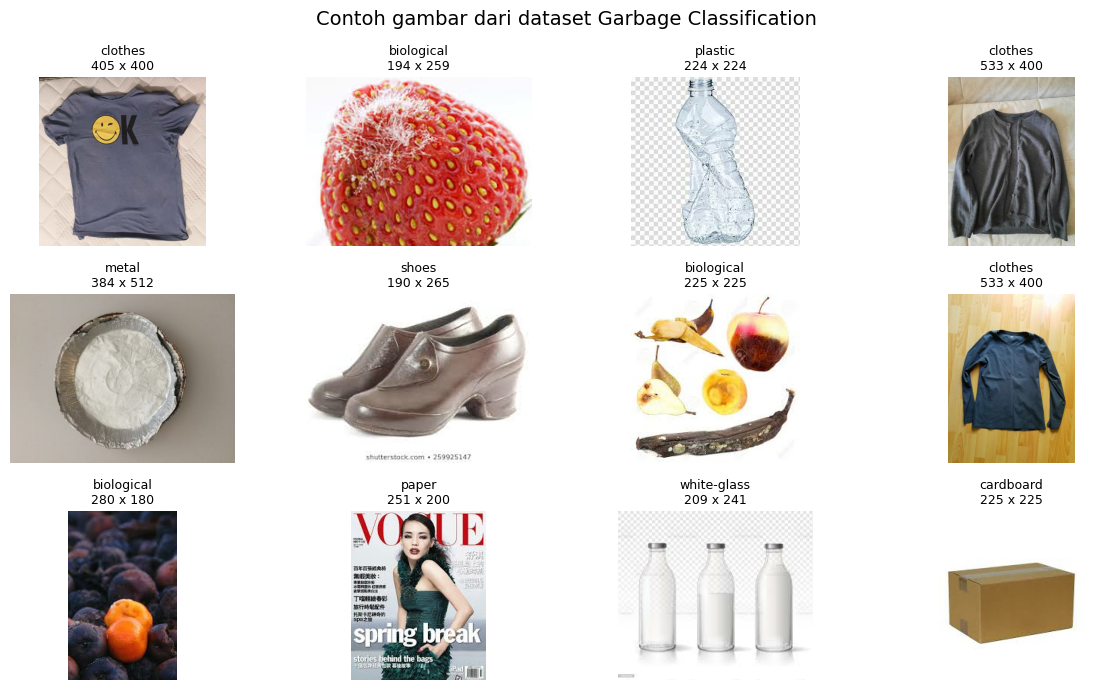

In [12]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(file_paths), size=12, replace=False)

plt.figure(figsize=(12, 7))
for plot_index, data_index in enumerate(sample_indices, start=1):
    image_path = file_paths[data_index]
    label = labels[data_index]

    image = tf.io.decode_image(tf.io.read_file(image_path), channels=3, expand_animations=False)
    height, width = tf.shape(image).numpy()[:2]

    plt.subplot(3, 4, plot_index)
    plt.imshow(image.numpy())
    plt.title(f"{CLASS_NAMES[label]}\n{height} x {width}", fontsize=9)
    plt.axis("off")

plt.suptitle("Contoh gambar dari dataset Garbage Classification", fontsize=14)
plt.tight_layout()
plt.show()

### Data Preprocessing

Data dibagi ulang secara manual menjadi train, validation, dan test set dengan rasio 70%, 15%, dan 15%. Pembagian dilakukan secara stratified agar proporsi setiap kelas tetap seimbang. Setelah itu, gambar dibaca dari file, di-resize ke ukuran input EfficientNetB0, dan diubah menjadi `float32`.

#### Split Dataset

Komposisi akhir dataset setelah pembagian manual:

- Train set: 70% dari seluruh data
- Validation set: 15% dari seluruh data
- Test set: 15% dari seluruh data

In [13]:
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

indices = np.arange(TOTAL_IMAGES)

train_indices, split_indices = train_test_split(
    indices,
    test_size=VALIDATION_RATIO + TEST_RATIO,
    random_state=SEED,
    shuffle=True,
    stratify=labels,
)

val_indices, test_indices = train_test_split(
    split_indices,
    test_size=TEST_RATIO / (VALIDATION_RATIO + TEST_RATIO),
    random_state=SEED,
    shuffle=True,
    stratify=labels[split_indices],
)

train_paths = file_paths[train_indices]
train_labels = labels[train_indices]
val_paths = file_paths[val_indices]
val_labels = labels[val_indices]
test_paths = file_paths[test_indices]
test_labels = labels[test_indices]

print(f"Train set      : {len(train_paths)} gambar")
print(f"Validation set : {len(val_paths)} gambar")
print(f"Test set       : {len(test_paths)} gambar")

Train set      : 10860 gambar
Validation set : 2327 gambar
Test set       : 2328 gambar


In [14]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomContrast(0.10, seed=SEED),
    ],
    name="data_augmentation",
)


def load_image(image_path, label):
    image = tf.io.decode_image(tf.io.read_file(image_path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.int32)


def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)

    if training:
        ds = ds.map(
            lambda batch_images, batch_labels: (
                data_augmentation(batch_images, training=True),
                batch_labels,
            ),
            num_parallel_calls=AUTOTUNE,
        )

    return ds.prefetch(AUTOTUNE)


train_ds = build_dataset(train_paths, train_labels, training=True)
train_eval_ds = build_dataset(train_paths, train_labels)
val_ds = build_dataset(val_paths, val_labels)
test_ds = build_dataset(test_paths, test_labels)

sample_batch, sample_labels = next(iter(train_ds))
print("Batch image shape:", sample_batch.shape)
print("Batch label shape:", sample_labels.shape)
print("Rentang nilai piksel:", float(tf.reduce_min(sample_batch)), "sampai", float(tf.reduce_max(sample_batch)))

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Rentang nilai piksel: 0.0 sampai 255.0


## Modelling

Model dibuat menggunakan `tf.keras.Sequential` dengan EfficientNetB0 sebagai backbone transfer learning. EfficientNetB0 memakai bobot ImageNet, kemudian ditambahkan head klasifikasi yang terdiri dari `Conv2D`, `BatchNormalization`, aktivasi ReLU, `GlobalAveragePooling2D`, dropout, dan dense layer sesuai jumlah kelas.

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE,
)
base_model.trainable = False

model = tf.keras.Sequential(
    [
        layers.Input(shape=IMG_SHAPE),
        base_model,
        layers.Conv2D(
            256,
            3,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name="head_conv2d",
        ),
        layers.BatchNormalization(name="head_batch_norm"),
        layers.Activation("relu", name="head_relu"),
        layers.GlobalAveragePooling2D(name="head_global_average_pooling"),
        layers.Dropout(0.35, name="head_dropout"),
        layers.Dense(NUM_CLASSES, activation="softmax", name="classifier"),
    ],
    name="garbage_efficientnetb0_sequential",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "garbage_efficientnetb0_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_conv2d (Conv2D)            │ (None, 7, 7, 256)      │     2,949,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_relu (Activation)          │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_global_average_pooling     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,002,799 (26.71 MB)

 Trainable params: 2,952,716 (11.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

### Training Model

Training dilakukan dalam dua tahap. Tahap pertama melatih head classifier dengan backbone EfficientNetB0 dibekukan. Tahap kedua membuka sebagian layer akhir backbone dengan learning rate kecil agar model dapat menyesuaikan fitur terhadap dataset Garbage Classification.

In [16]:
class StopWhenTargetReached(tf.keras.callbacks.Callback):
    # Menghentikan training saat akurasi train dan validation sudah mencapai target.
    def __init__(self, train_target=0.97, val_target=0.95):
        super().__init__()
        self.train_target = train_target
        self.val_target = val_target

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc = logs.get("accuracy", 0.0)
        val_acc = logs.get("val_accuracy", 0.0)
        if train_acc >= self.train_target and val_acc >= self.val_target:
            print(
                f"\nTarget tercapai pada epoch {epoch + 1}: "
                f"accuracy={train_acc:.4f}, val_accuracy={val_acc:.4f}"
            )
            self.model.stop_training = True


CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_garbage_efficientnetb0.keras"


def build_callbacks():
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(BEST_MODEL_PATH),
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=8,
            restore_best_weights=True,
            mode="max",
            verbose=1,
        ),
        StopWhenTargetReached(train_target=0.97, val_target=0.95),
    ]


INITIAL_EPOCHS = 10
history_initial = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS,
    validation_data=val_ds,
    callbacks=build_callbacks(),
    verbose=1,
)

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

FINE_TUNE_EPOCHS = 20
history_fine = model.fit(
    train_ds,
    initial_epoch=INITIAL_EPOCHS,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    validation_data=val_ds,
    callbacks=build_callbacks(),
    verbose=1,
)

history = {}
for phase_history in [history_initial, history_fine]:
    for key, values in phase_history.history.items():
        history.setdefault(key, []).extend(values)

if BEST_MODEL_PATH.exists():
    model = tf.keras.models.load_model(str(BEST_MODEL_PATH))
    print(f"Model terbaik dimuat dari: {BEST_MODEL_PATH}")

Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8624 - loss: 0.4606
Epoch 1: val_accuracy improved from None to 0.95402, saving model to checkpoints/best_garbage_efficientnetb0.keras

Epoch 1: finished saving model to checkpoints/best_garbage_efficientnetb0.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 94s 220ms/step - accuracy: 0.9112 - loss: 0.3035 - val_accuracy: 0.9540 - val_loss: 0.1489 - learning_rate: 0.0010
Epoch 2/10
339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9536 - loss: 0.1571
Epoch 2: val_accuracy improved from 0.95402 to 0.95960, saving model to checkpoints/best_garbage_efficientnetb0.keras

Epoch 2: finished saving model to checkpoints/best_garbage_efficientnetb0.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 56s 163ms/step - accuracy: 0.9501 - loss: 0.1600 - val_accuracy: 0.9596 - val_loss: 0.1378 - learning_rate: 0.0010
Epoch 3/10
339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9588 - loss: 0.1334
Epoch 3: val_accuracy did not improve from 0.95960
34

## Evaluasi dan Visualisasi

Evaluasi dilakukan pada train, validation, dan test set. Plot akurasi dan loss membantu melihat apakah model sudah belajar stabil atau mulai overfitting.

In [17]:
train_loss, train_acc = model.evaluate(train_eval_ds, verbose=1)
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print("\nHasil evaluasi model:")
print(f"- Train accuracy: {train_acc:.4f}")
print(f"- Validation accuracy: {val_acc:.4f}")
print(f"- Test accuracy: {test_acc:.4f}")
print(f"- Train loss: {train_loss:.4f}")
print(f"- Validation loss: {val_loss:.4f}")
print(f"- Test loss: {test_loss:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.9845 - loss: 0.0538
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9613 - loss: 0.1209
71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9603 - loss: 0.1206

2026-06-21 09:40:34.428605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 09:40:34.569962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 09:40:34.905062: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 09:40:35.046522: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 09:40:35.827442: E external/local_xla/xla/stream_

73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - accuracy: 0.9648 - loss: 0.1147

Hasil evaluasi model:
- Train accuracy: 0.9845
- Validation accuracy: 0.9613
- Test accuracy: 0.9648
- Train loss: 0.0538
- Validation loss: 0.1209
- Test loss: 0.1147


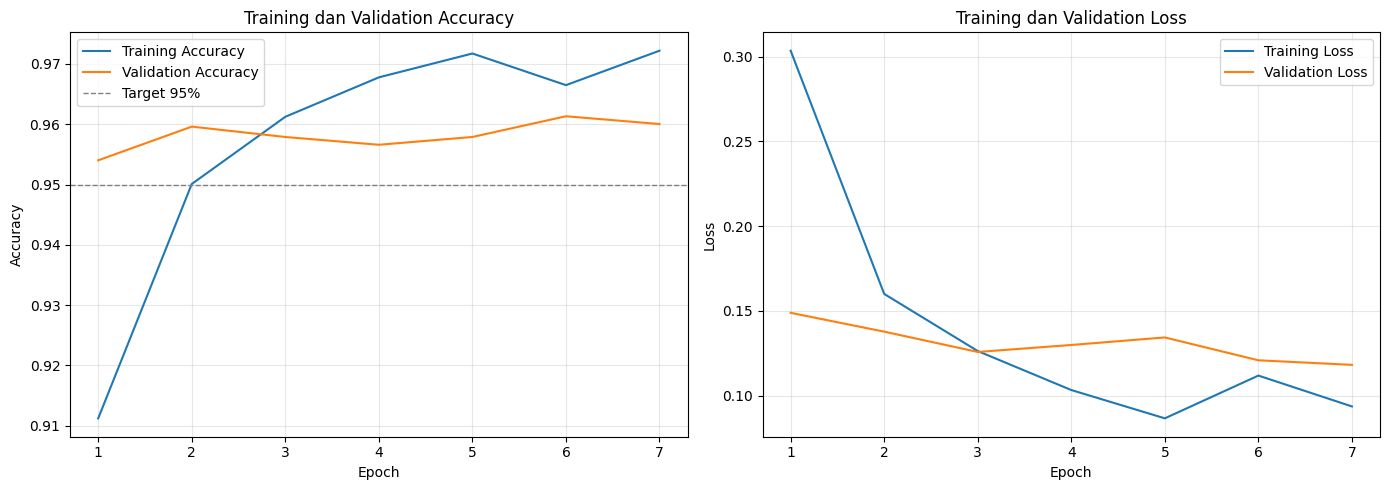

In [18]:
acc = history.get("accuracy", [])
val_acc = history.get("val_accuracy", [])
loss = history.get("loss", [])
val_loss = history.get("val_loss", [])
epoch_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc, label="Training Accuracy")
plt.plot(epoch_range, val_acc, label="Validation Accuracy")
plt.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="Target 95%")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training dan Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss, label="Training Loss")
plt.plot(epoch_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training dan Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

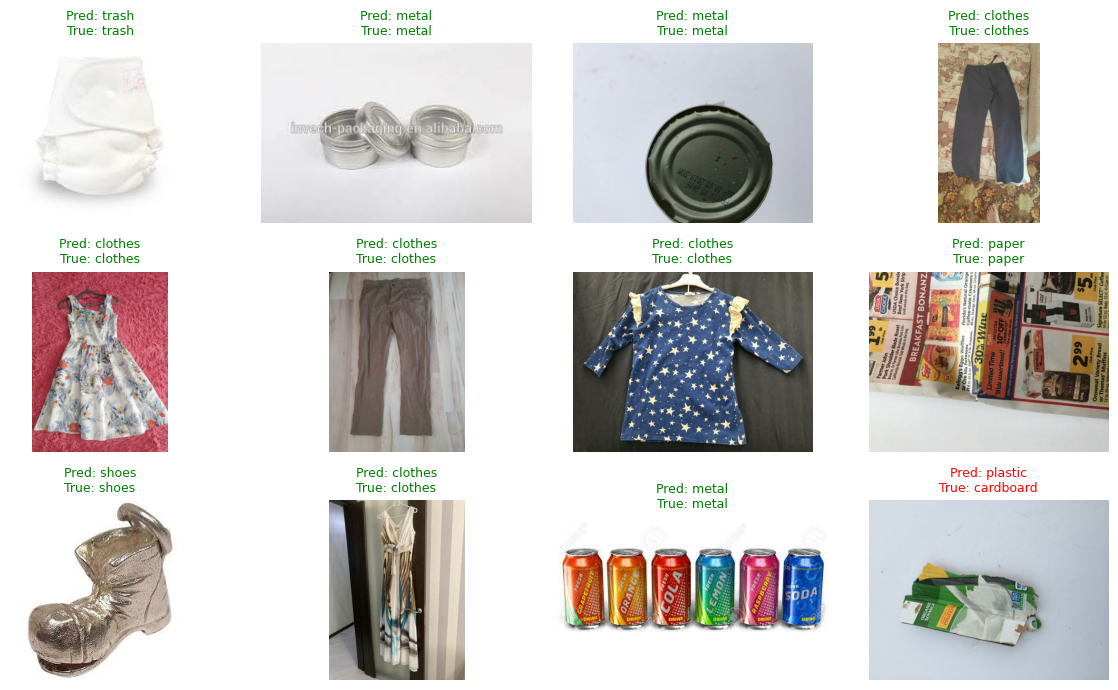

In [19]:
def load_image_for_prediction(image_path):
    raw_image = tf.io.decode_image(tf.io.read_file(image_path), channels=3, expand_animations=False)
    input_image = tf.image.resize(raw_image, IMG_SIZE)
    input_image = tf.cast(input_image, tf.float32)
    return raw_image, input_image


def show_prediction_examples(model, paths, labels, class_names, total=12):
    selected_paths = paths[:total]
    selected_labels = labels[:total]

    raw_images = []
    input_images = []
    for image_path in selected_paths:
        raw_image, input_image = load_image_for_prediction(image_path)
        raw_images.append(raw_image.numpy())
        input_images.append(input_image.numpy())

    probabilities = model.predict(np.array(input_images), verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)

    plt.figure(figsize=(12, 7))
    for i in range(total):
        color = "green" if predicted_labels[i] == selected_labels[i] else "red"
        plt.subplot(3, 4, i + 1)
        plt.imshow(raw_images[i])
        plt.title(
            f"Pred: {class_names[predicted_labels[i]]}\nTrue: {class_names[selected_labels[i]]}",
            color=color,
            fontsize=9,
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_prediction_examples(model, test_paths, test_labels, CLASS_NAMES, total=12)

## Konversi Model

Model disimpan dalam tiga format yang diminta: SavedModel, TensorFlow Lite, dan TensorFlow.js. Folder output mengikuti struktur submission yang disarankan.

In [22]:
SAVED_MODEL_DIR = Path("saved_model")
TFLITE_DIR = Path("tflite")
TFJS_DIR = Path("tfjs_model")

for output_dir in [SAVED_MODEL_DIR, TFLITE_DIR, TFJS_DIR]:
    if output_dir.exists():
        shutil.rmtree(output_dir)

TFLITE_DIR.mkdir(parents=True, exist_ok=True)

# SavedModel
if hasattr(model, "export"):
    model.export(str(SAVED_MODEL_DIR))
else:
    tf.saved_model.save(model, str(SAVED_MODEL_DIR))

print(f"SavedModel disimpan di: {SAVED_MODEL_DIR}")

# TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

TFLITE_MODEL_PATH = TFLITE_DIR / "model.tflite"
TFLITE_MODEL_PATH.write_bytes(tflite_model)

LABEL_PATH = TFLITE_DIR / "label.txt"
LABEL_PATH.write_text("\n".join(CLASS_NAMES.tolist()), encoding="utf-8")

print(f"TFLite model disimpan di: {TFLITE_MODEL_PATH}")
print(f"Label disimpan di: {LABEL_PATH}")

# TensorFlow.js
try:
    import tensorflowjs as tfjs

    tfjs.converters.save_keras_model(model, str(TFJS_DIR))
    print(f"TFJS model disimpan di: {TFJS_DIR}")
except Exception as error:
    print("Konversi TFJS via Python API gagal, mencoba CLI tensorflowjs_converter...")
    converter_cli = shutil.which("tensorflowjs_converter")
    if converter_cli is None:
        raise RuntimeError(
            "Install package tensorflowjs terlebih dahulu, lalu jalankan ulang cell ini."
        ) from error

    subprocess.run(
        [
            converter_cli,
            "--input_format=tf_saved_model",
            "--output_format=tfjs_graph_model",
            str(SAVED_MODEL_DIR),
            str(TFJS_DIR),
        ],
        check=True,
    )
    print(f"TFJS model disimpan di: {TFJS_DIR}")

INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  139782601399696: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139782601404880: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139782740756624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740758352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740756816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740759504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740760080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740760272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740757968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139782740759696: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

W0000 00:00:1782035330.577471     523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782035330.577539     523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TFLite model disimpan di: tflite/model.tflite
Label disimpan di: tflite/label.txt


failed to lookup keras version from the file,
    this is likely a weight only file
weight normalization_1/count with shape () and dtype int64 was auto converted to the type int32
TFJS model disimpan di: tfjs_model


## Inference

Bagian ini menjadi bukti bahwa model yang sudah dikonversi dapat dipakai untuk prediksi. Contoh di bawah menggunakan model TFLite karena format ini ringan dan umum dipakai untuk deployment mobile.

Hasil inference menggunakan TFLite
Label asli      : trash
Prediksi model  : trash
Confidence      : 0.9976


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


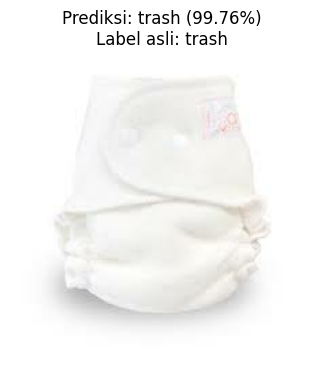

In [23]:
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_index = 0
sample_path = test_paths[sample_index]
true_label = CLASS_NAMES[test_labels[sample_index]]
raw_image, input_image = load_image_for_prediction(sample_path)

input_data = np.expand_dims(input_image.numpy(), axis=0).astype(input_details[0]["dtype"])
interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]["index"])[0]
predicted_index = int(np.argmax(output_data))
predicted_label = CLASS_NAMES[predicted_index]
confidence = float(np.max(output_data))

print("Hasil inference menggunakan TFLite")
print(f"Label asli      : {true_label}")
print(f"Prediksi model  : {predicted_label}")
print(f"Confidence      : {confidence:.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(raw_image.numpy())
plt.title(f"Prediksi: {predicted_label} ({confidence:.2%})\nLabel asli: {true_label}")
plt.axis("off")
plt.show()